## Importing Libraries 

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, GRU, SimpleRNN, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

import warnings
warnings.filterwarnings('ignore')

## Loading Dataset 

In [33]:
df = pd.read_csv(r'spacex.csv')
df

,Datetime,Close,High,Low,Open,Volume
0,2026-06-12 15:30:00+00:00,161.309998,168.750000,150.000000,150.000000,90004242
1,2026-06-12 16:00:00+00:00,164.968994,167.770004,155.419998,161.350006,88532026
2,2026-06-12 16:30:00+00:00,173.740005,174.000000,163.070007,164.960007,56616741
3,2026-06-12 17:00:00+00:00,172.279999,176.520004,169.460007,173.720001,44169592
4,2026-06-12 17:30:00+00:00,173.330002,174.000000,168.000000,172.285004,26438783
5,2026-06-12 18:00:00+00:00,169.199997,173.360001,165.050003,173.360001,29089217
6,2026-06-12 18:30:00+00:00,168.850006,170.940002,166.300003,169.294998,21655936
7,2026-06-12 19:00:00+00:00,161.440002,169.229996,161.309998,168.889999,32934441
8,2026-06-12 19:30:00+00:00,161.270004,162.770004,157.440002,161.460007,44594464
9,2026-06-15 13:30:00+00:00,173.630005,175.000000,168.360001,171.809998,60110813


## EDA

In [34]:
df.head()

,Datetime,Close,High,Low,Open,Volume
0,2026-06-12 15:30:00+00:00,161.309998,168.750000,150.000000,150.000000,90004242
1,2026-06-12 16:00:00+00:00,164.968994,167.770004,155.419998,161.350006,88532026
2,2026-06-12 16:30:00+00:00,173.740005,174.000000,163.070007,164.960007,56616741
3,2026-06-12 17:00:00+00:00,172.279999,176.520004,169.460007,173.720001,44169592
4,2026-06-12 17:30:00+00:00,173.330002,174.000000,168.000000,172.285004,26438783


In [35]:
df.shape

(35, 6)

In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35 entries, 0 to 34
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Datetime  35 non-null     object 
 1   Close     35 non-null     float64
 2   High      35 non-null     float64
 3   Low       35 non-null     float64
 4   Open      35 non-null     float64
 5   Volume    35 non-null     int64  
dtypes: float64(4), int64(1), object(1)
memory usage: 1.8+ KB


In [37]:
df.describe()

,Close,High,Low,Open,Volume
count,35.000000,35.000000,35.000000,35.000000,3.500000e+01
mean,188.556946,191.416715,184.021458,187.597157,2.793775e+07
std,19.293304,19.728379,19.481295,19.972308,2.377263e+07
min,161.270004,162.770004,150.000000,150.000000,7.902359e+06
25%,173.465004,174.040001,168.779999,172.822502,1.262921e+07
50%,183.399994,187.860001,181.539993,183.320007,1.692419e+07
75%,209.099998,213.059998,205.075005,209.082497,3.101183e+07
max,219.000000,225.639999,213.699997,218.809998,9.375127e+07


In [38]:
df.isnull().sum()

Datetime    0
Close       0
High        0
Low         0
Open        0
Volume      0
dtype: int64

## Data Cleaning & Feature Engineering

In [39]:
df['Datetime'] = pd.to_datetime(df['Datetime'])
df['Date'] = df['Datetime'].dt.date
df['Hour'] = df['Datetime'].dt.hour
df['Minute'] = df['Datetime'].dt.minute

df['Price_Range'] = df['High'] - df['Low']
df['Price_Change'] = df['Close'] - df['Open']
df['Pct_Change'] = ((df['Close'] - df['Open']) / df['Open']) * 100

print("After cleaning records:", len(df))
df.head()

After cleaning records: 35


,Datetime,Close,High,Low,Open,Volume,Date,Hour,Minute,Price_Range,Price_Change,Pct_Change
0,2026-06-12 15:30:00+00:00,161.309998,168.750000,150.000000,150.000000,90004242,2026-06-12,15,30,18.750000,11.309998,7.539998
1,2026-06-12 16:00:00+00:00,164.968994,167.770004,155.419998,161.350006,88532026,2026-06-12,16,0,12.350006,3.618988,2.242943
2,2026-06-12 16:30:00+00:00,173.740005,174.000000,163.070007,164.960007,56616741,2026-06-12,16,30,10.929993,8.779999,5.322501
3,2026-06-12 17:00:00+00:00,172.279999,176.520004,169.460007,173.720001,44169592,2026-06-12,17,0,7.059998,-1.440002,-0.828922
4,2026-06-12 17:30:00+00:00,173.330002,174.000000,168.000000,172.285004,26438783,2026-06-12,17,30,6.000000,1.044998,0.606552


## Stock Price Trend

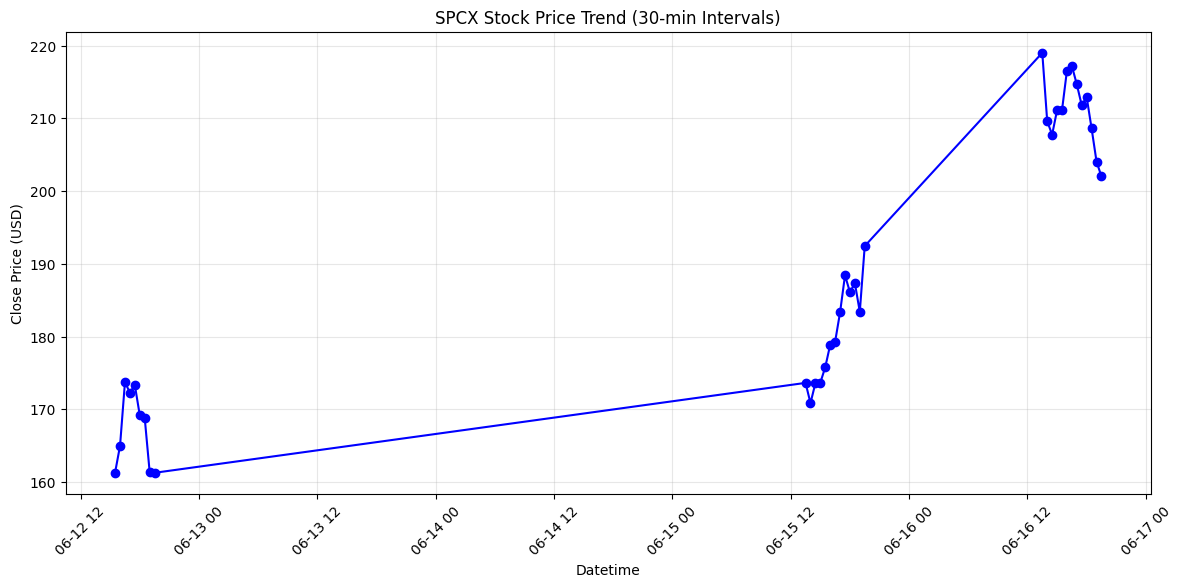

In [40]:
plt.figure(figsize=(14, 6))
plt.plot(df['Datetime'], df['Close'], marker='o', linestyle='-', linewidth=1.5, color='blue')
plt.xlabel('Datetime')
plt.ylabel('Close Price (USD)')
plt.title('SPCX Stock Price Trend (30-min Intervals)')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.show()

## OHLC Summary

In [41]:
print("OHLC Summary Statistics:")
print(f"Average Open: ${df['Open'].mean():.2f}")
print(f"Average High: ${df['High'].mean():.2f}")
print(f"Average Low: ${df['Low'].mean():.2f}")
print(f"Average Close: ${df['Close'].mean():.2f}")
print(f"\nAverage Price Range: ${df['Price_Range'].mean():.2f}")
print(f"Max Price Range: ${df['Price_Range'].max():.2f}")

OHLC Summary Statistics:
Average Open: $187.60
Average High: $191.42
Average Low: $184.02
Average Close: $188.56

Average Price Range: $7.40
Max Price Range: $20.02


## Volume Analysis

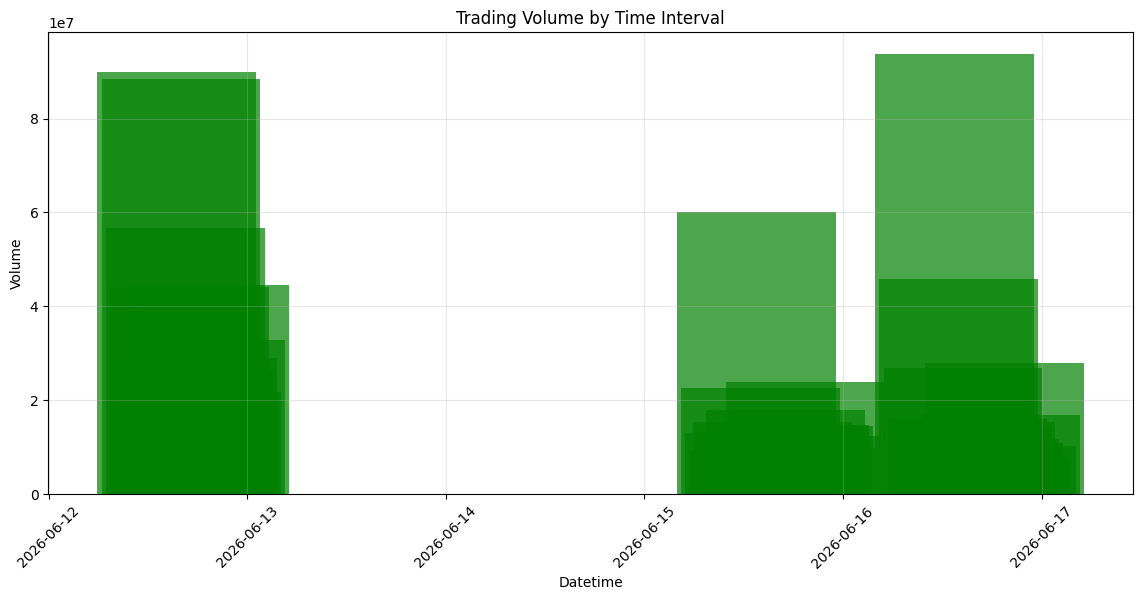

In [42]:
plt.figure(figsize=(14, 6))
plt.bar(df['Datetime'], df['Volume'], alpha=0.7, color='green')
plt.xlabel('Datetime')
plt.ylabel('Volume')
plt.title('Trading Volume by Time Interval')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.show()

## Correlation Heatmap

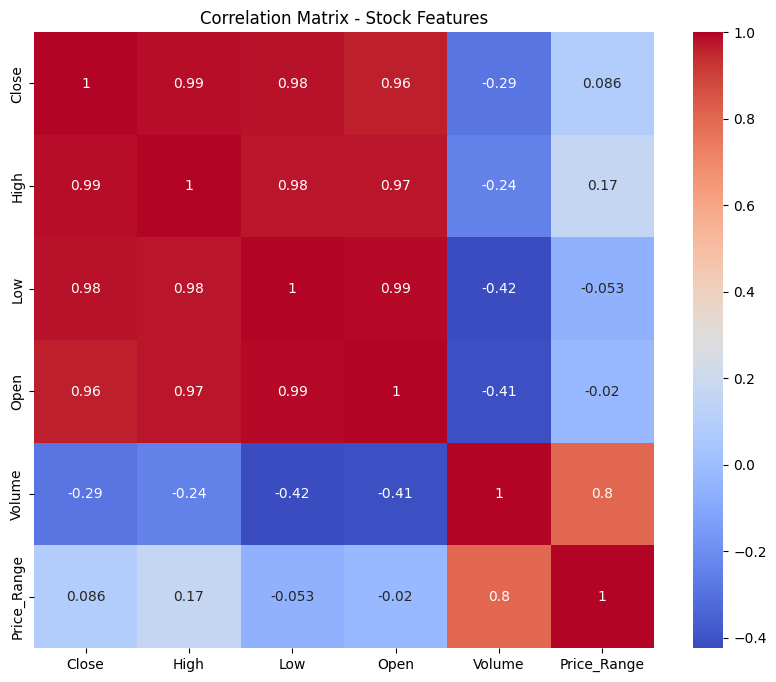

In [43]:
plt.figure(figsize=(10, 8))
sns.heatmap(df[['Close', 'High', 'Low', 'Open', 'Volume', 'Price_Range']].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix - Stock Features')
plt.show()

## Price Distribution

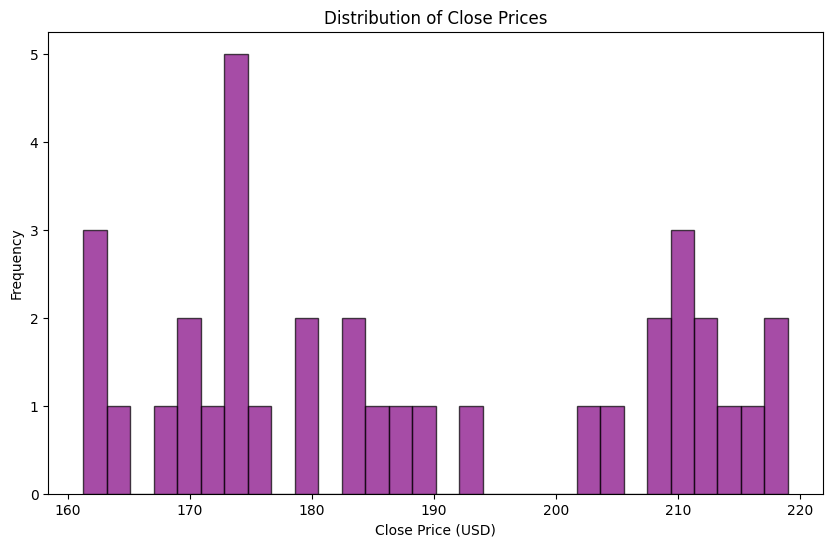

In [44]:
plt.figure(figsize=(10, 6))
plt.hist(df['Close'], bins=30, edgecolor='black', alpha=0.7, color='purple')
plt.xlabel('Close Price (USD)')
plt.ylabel('Frequency')
plt.title('Distribution of Close Prices')
plt.show()

## Data Preparation for Deep Learning

In [45]:
data = df['Close'].values.reshape(-1, 1)

scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data)

def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
    return np.array(X), np.array(y)

SEQ_LENGTH = 10
X, y = create_sequences(scaled_data, SEQ_LENGTH)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (20, 10, 1)
X_test shape: (5, 10, 1)
y_train shape: (20, 1)
y_test shape: (5, 1)


## RNN Model - SimpleRNN

In [46]:
rnn_model = Sequential([
    SimpleRNN(50, activation='tanh', return_sequences=True, input_shape=(SEQ_LENGTH, 1)),
    Dropout(0.2),
    SimpleRNN(50, activation='tanh'),
    Dropout(0.2),
    Dense(1)
])

rnn_model.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history_rnn = rnn_model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=8,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

print("RNN Model Summary:")
rnn_model.summary()

Epoch 1/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 201ms/step - loss: 0.4113 - mae: 0.4290 - val_loss: 0.0899 - val_mae: 0.2961
Epoch 2/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 0.2055 - mae: 0.3040 - val_loss: 5.3722e-04 - val_mae: 0.0206
Epoch 3/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 0.1162 - mae: 0.2705 - val_loss: 0.0383 - val_mae: 0.1812
Epoch 4/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.2145 - mae: 0.3461 - val_loss: 0.0094 - val_mae: 0.0959
Epoch 5/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.1271 - mae: 0.2722 - val_loss: 0.0688 - val_mae: 0.2610
Epoch 6/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 0.1192 - mae: 0.2997 - val_loss: 0.0219 - val_mae: 0.1470
Epoch 7/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.1209 - mae: 0.2696 - val_loss: 0.0069 - val_mae: 0.0827
Epoch 8/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.1025 - mae: 0.2414 - val_loss: 0.0059 - val_mae: 0.0726
Epoch 9/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.1202 - mae: 0.27

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_2 (SimpleRNN)        │ (None, 10, 50)         │         2,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 10, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_3 (SimpleRNN)        │ (None, 50)             │         5,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,105 (90.26 KB)

 Trainable params: 7,701 (30.08 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 15,404 (60.18 KB)

## RNN Model Evaluation

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 281ms/step
RNN MODEL EVALUATION
Mean Squared Error: 47.9222
Root Mean Squared Error: 6.9226
R² Score: 0.7576


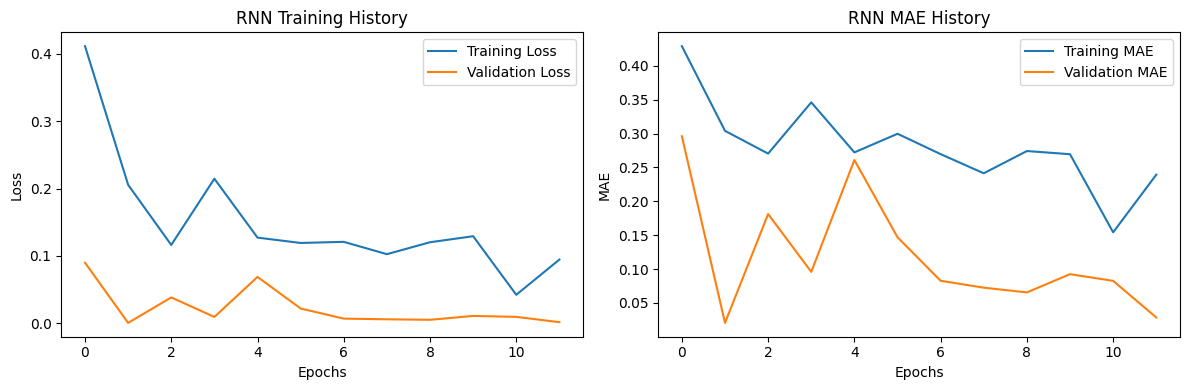

In [47]:
rnn_pred = rnn_model.predict(X_test)

rnn_pred_actual = scaler.inverse_transform(rnn_pred)
y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1))

rnn_mse = mean_squared_error(y_test_actual, rnn_pred_actual)
rnn_rmse = np.sqrt(rnn_mse)
rnn_r2 = r2_score(y_test_actual, rnn_pred_actual)

print("RNN MODEL EVALUATION")
print(f"Mean Squared Error: {rnn_mse:.4f}")
print(f"Root Mean Squared Error: {rnn_rmse:.4f}")
print(f"R² Score: {rnn_r2:.4f}")

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history_rnn.history['loss'], label='Training Loss')
plt.plot(history_rnn.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('RNN Training History')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_rnn.history['mae'], label='Training MAE')
plt.plot(history_rnn.history['val_mae'], label='Validation MAE')
plt.xlabel('Epochs')
plt.ylabel('MAE')
plt.title('RNN MAE History')
plt.legend()
plt.tight_layout()
plt.show()

## LSTM Model

In [48]:
lstm_model = Sequential([
    LSTM(50, activation='tanh', return_sequences=True, input_shape=(SEQ_LENGTH, 1)),
    Dropout(0.2),
    LSTM(50, activation='tanh'),
    Dropout(0.2),
    Dense(1)
])

lstm_model.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])

history_lstm = lstm_model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=8,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)
print("\nLSTM Model Summary:")
lstm_model.summary()

Epoch 1/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 184ms/step - loss: 0.4631 - mae: 0.6169 - val_loss: 0.3764 - val_mae: 0.5658
Epoch 2/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.3407 - mae: 0.5204 - val_loss: 0.2486 - val_mae: 0.4597
Epoch 3/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 0.2196 - mae: 0.4074 - val_loss: 0.1346 - val_mae: 0.3377
Epoch 4/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.1266 - mae: 0.2851 - val_loss: 0.0388 - val_mae: 0.1800
Epoch 5/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.0472 - mae: 0.1599 - val_loss: 9.6767e-04 - val_mae: 0.0307
Epoch 6/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.0691 - mae: 0.2187 - val_loss: 0.0310 - val_mae: 0.1671
Epoch 7/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.0596 - mae: 0.2041 - val_loss: 0.0116 - val_mae: 0.1045
Epoch 8/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.0452 - mae: 0.1788 - val_loss: 2.1852e-04 - val_mae: 0.0147
Epoch 9/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.0468 - mae: 

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 10, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 10, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 91,955 (359.20 KB)

 Trainable params: 30,651 (119.73 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 61,304 (239.47 KB)

## LSTM Model Evaluation

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 221ms/step
LSTM MODEL EVALUATION
Mean Squared Error: 91.2189
Root Mean Squared Error: 9.5509
R² Score: 0.5386


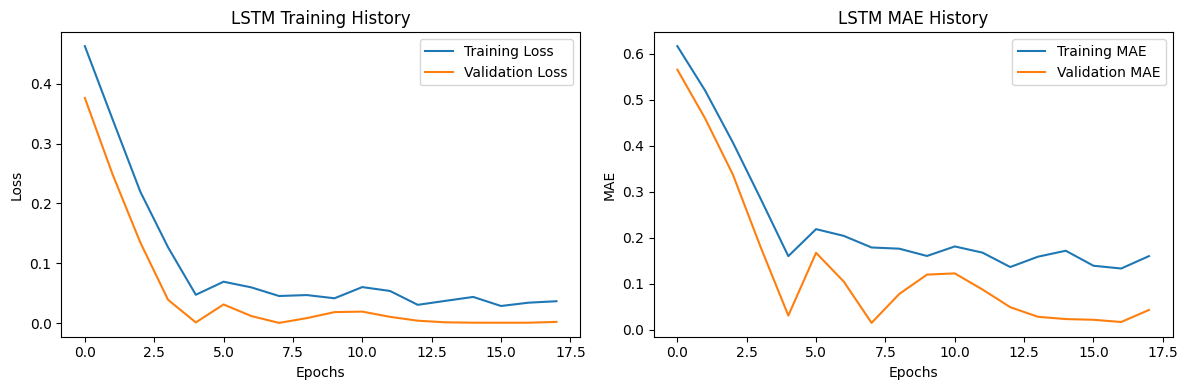

In [49]:
lstm_pred = lstm_model.predict(X_test)

lstm_pred_actual = scaler.inverse_transform(lstm_pred)
y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1))

lstm_mse = mean_squared_error(y_test_actual, lstm_pred_actual)
lstm_rmse = np.sqrt(lstm_mse)
lstm_r2 = r2_score(y_test_actual, lstm_pred_actual)

print("LSTM MODEL EVALUATION")
print("="*50)
print(f"Mean Squared Error: {lstm_mse:.4f}")
print(f"Root Mean Squared Error: {lstm_rmse:.4f}")
print(f"R² Score: {lstm_r2:.4f}")

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history_lstm.history['loss'], label='Training Loss')
plt.plot(history_lstm.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('LSTM Training History')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_lstm.history['mae'], label='Training MAE')
plt.plot(history_lstm.history['val_mae'], label='Validation MAE')
plt.xlabel('Epochs')
plt.ylabel('MAE')
plt.title('LSTM MAE History')
plt.legend()
plt.tight_layout()
plt.show()

## GRU Model

In [50]:
gru_model = Sequential([
    GRU(50, activation='tanh', return_sequences=True, input_shape=(SEQ_LENGTH, 1)),
    Dropout(0.2),
    GRU(50, activation='tanh'),
    Dropout(0.2),
    Dense(1)
])
gru_model.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])
history_gru = gru_model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=8,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)
print("GRU Model Summary:")
gru_model.summary()

Epoch 1/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 199ms/step - loss: 0.3885 - mae: 0.5622 - val_loss: 0.2225 - val_mae: 0.4358
Epoch 2/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 0.1797 - mae: 0.3755 - val_loss: 0.0553 - val_mae: 0.2164
Epoch 3/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.0899 - mae: 0.2048 - val_loss: 2.7425e-04 - val_mae: 0.0165
Epoch 4/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 0.0235 - mae: 0.1271 - val_loss: 0.0528 - val_mae: 0.2153
Epoch 5/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.0504 - mae: 0.1933 - val_loss: 0.0828 - val_mae: 0.2686
Epoch 6/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 0.0911 - mae: 0.2623 - val_loss: 0.0422 - val_mae: 0.1913
Epoch 7/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 0.0560 - mae: 0.1901 - val_loss: 0.0065 - val_mae: 0.0739
Epoch 8/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 0.0356 - mae: 0.1444 - val_loss: 6.1746e-04 - val_mae: 0.0242
Epoch 9/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 0.0308 - mae: 

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_4 (GRU)                     │ (None, 10, 50)         │         7,950 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 10, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_5 (GRU)                     │ (None, 50)             │        15,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 69,905 (273.07 KB)

 Trainable params: 23,301 (91.02 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 46,604 (182.05 KB)

## GRU Model Evaluation

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 262ms/step
GRU MODEL EVALUATION
Mean Squared Error: 497.2451
Root Mean Squared Error: 22.2990
R² Score: -1.5150


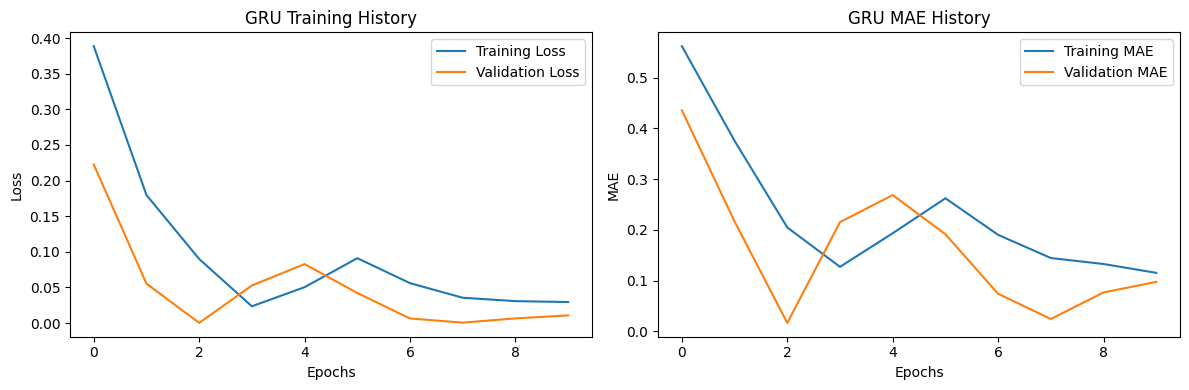

In [51]:
gru_pred = gru_model.predict(X_test)

gru_pred_actual = scaler.inverse_transform(gru_pred)
y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1))

gru_mse = mean_squared_error(y_test_actual, gru_pred_actual)
gru_rmse = np.sqrt(gru_mse)
gru_r2 = r2_score(y_test_actual, gru_pred_actual)

print("GRU MODEL EVALUATION")
print(f"Mean Squared Error: {gru_mse:.4f}")
print(f"Root Mean Squared Error: {gru_rmse:.4f}")
print(f"R² Score: {gru_r2:.4f}")

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history_gru.history['loss'], label='Training Loss')
plt.plot(history_gru.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('GRU Training History')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_gru.history['mae'], label='Training MAE')
plt.plot(history_gru.history['val_mae'], label='Validation MAE')
plt.xlabel('Epochs')
plt.ylabel('MAE')
plt.title('GRU MAE History')
plt.legend()
plt.tight_layout()
plt.show()

## Model Comparison

In [52]:
comparison = pd.DataFrame({
    'Model': ['RNN', 'LSTM', 'GRU'],
    'MSE': [rnn_mse, lstm_mse, gru_mse],
    'RMSE': [rnn_rmse, lstm_rmse, gru_rmse],
    'R2_Score': [rnn_r2, lstm_r2, gru_r2]
})
print("MODEL COMPARISON SUMMARY")
print(comparison.to_string(index=False))
best_model = comparison.loc[comparison['R2_Score'].idxmax(), 'Model']
print(f"Best Model: {best_model} (R² Score: {comparison['R2_Score'].max():.4f})")

MODEL COMPARISON SUMMARY
Model        MSE      RMSE  R2_Score
  RNN  47.922249  6.922590  0.757611
 LSTM  91.218898  9.550858  0.538618
  GRU 497.245053 22.298992 -1.515048
Best Model: RNN (R² Score: 0.7576)


## Visualization - Actual vs Predicted

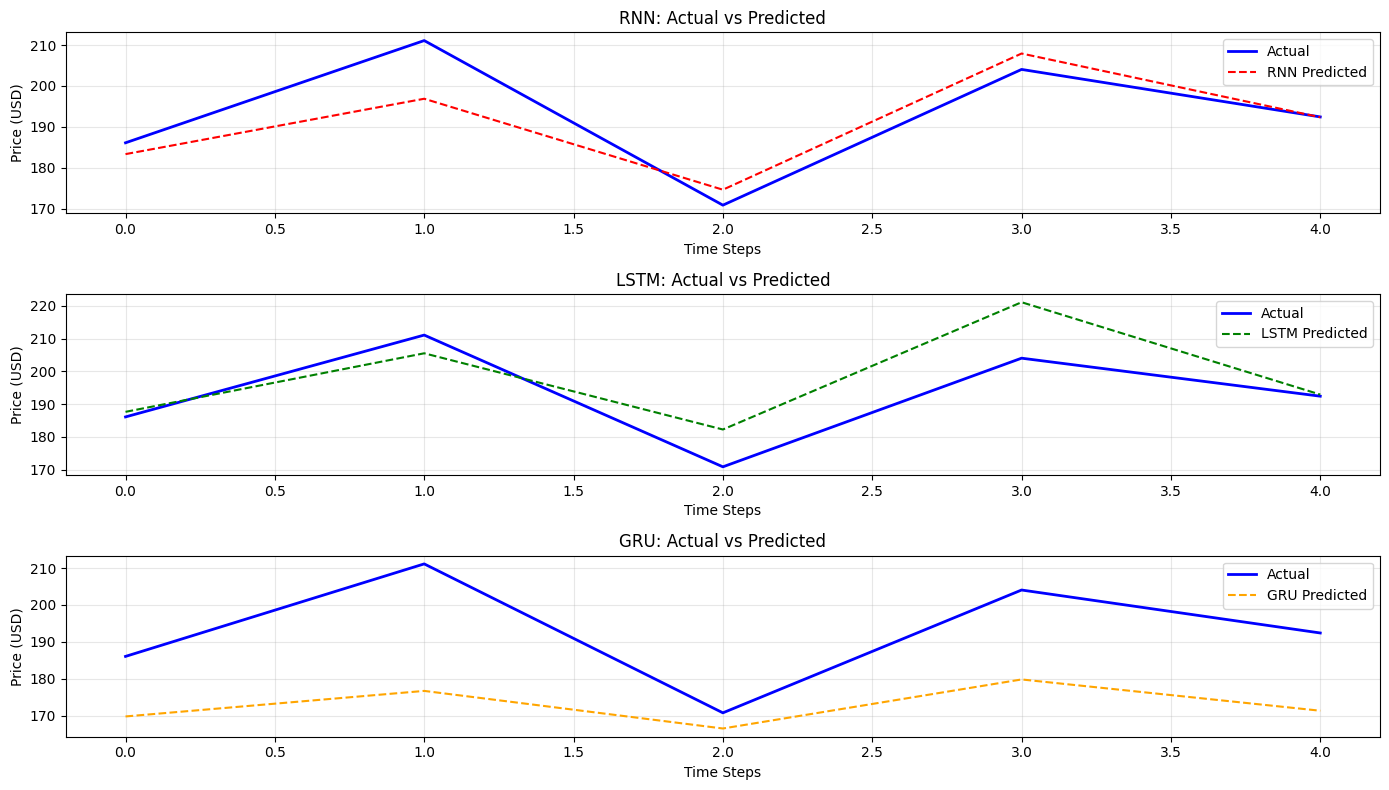

In [53]:
indices = np.arange(len(y_test_actual))

plt.figure(figsize=(14, 8))
plt.subplot(3, 1, 1)
plt.plot(indices, y_test_actual, label='Actual', color='blue', linewidth=2)
plt.plot(indices, rnn_pred_actual, label='RNN Predicted', color='red', linestyle='--', linewidth=1.5)
plt.xlabel('Time Steps')
plt.ylabel('Price (USD)')
plt.title('RNN: Actual vs Predicted')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(3, 1, 2)
plt.plot(indices, y_test_actual, label='Actual', color='blue', linewidth=2)
plt.plot(indices, lstm_pred_actual, label='LSTM Predicted', color='green', linestyle='--', linewidth=1.5)
plt.xlabel('Time Steps')
plt.ylabel('Price (USD)')
plt.title('LSTM: Actual vs Predicted')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(3, 1, 3)
plt.plot(indices, y_test_actual, label='Actual', color='blue', linewidth=2)
plt.plot(indices, gru_pred_actual, label='GRU Predicted', color='orange', linestyle='--', linewidth=1.5)
plt.xlabel('Time Steps')
plt.ylabel('Price (USD)')
plt.title('GRU: Actual vs Predicted')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Future Price Prediction

In [54]:
last_sequence = scaled_data[-SEQ_LENGTH:].reshape(1, SEQ_LENGTH, 1)
future_price_scaled = gru_model.predict(last_sequence)
future_price = scaler.inverse_transform(future_price_scaled)

print("FUTURE PRICE PREDICTION")
print(f"Last 10 intervals average: ${df['Close'].tail(10).mean():.2f}")
print(f"Current Price: ${df['Close'].iloc[-1]:.2f}")
print(f"Predicted Next Price: ${future_price[0][0]:.2f}")
print(f"Predicted Change: ${future_price[0][0] - df['Close'].iloc[-1]:.2f}")

if future_price[0][0] > df['Close'].iloc[-1]:
    print("Predicted: UP")
else:
    print("Predicted: DOWN")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 274ms/step
FUTURE PRICE PREDICTION
Last 10 intervals average: $211.00
Current Price: $202.00
Predicted Next Price: $179.02
Predicted Change: $-22.98
Predicted: DOWN


## Business Insights

In [56]:
print("BUSINESS INSIGHTS")

# Best performing hour
hourly_avg = df.groupby('Hour')['Close'].mean().sort_values(ascending=False)
print("Best Performing Hours (Average Close Price):")
print(hourly_avg.head(5))

# High volume periods
high_volume = df.nlargest(5, 'Volume')[['Datetime', 'Close', 'Volume']]
print("Highest Volume Periods:")
print(high_volume.to_string(index=False))

# Price movement
price_up = len(df[df['Price_Change'] > 0])
price_down = len(df[df['Price_Change'] < 0])
price_equal = len(df[df['Price_Change'] == 0])

print(f"Price Movement Statistics:")
print(f"Upward Movements: {price_up} ({price_up/len(df)*100:.1f}%)")
print(f"Downward Movements: {price_down} ({price_down/len(df)*100:.1f}%)")
print(f"No Change: {price_equal} ({price_equal/len(df)*100:.1f}%)")

BUSINESS INSIGHTS
Best Performing Hours (Average Close Price):
Hour
13    196.315002
17    190.634150
14    190.448753
18    188.836383
16    188.441366
Name: Close, dtype: float64
Highest Volume Periods:
                 Datetime      Close   Volume
2026-06-16 13:30:00+00:00 219.000000 93751266
2026-06-12 15:30:00+00:00 161.309998 90004242
2026-06-12 16:00:00+00:00 164.968994 88532026
2026-06-15 13:30:00+00:00 173.630005 60110813
2026-06-12 16:30:00+00:00 173.740005 56616741
Price Movement Statistics:
Upward Movements: 19 (54.3%)
Downward Movements: 16 (45.7%)
No Change: 0 (0.0%)
